# IND320 - Compulsory Work, Part 2

**Name:** Kittel Johannes Lande

**GitHub repository:** https://github.com/Kitteljl/IND320-app

**Streamlit app:** https://ind320-app-kittel.streamlit.app/

**Panopto Video:** TODO (add link)

This notebook documents the second compulsory hand-in for IND320. It covers setting up
Cassandra and Spark locally, MongoDB Atlas remotely, replacing the CSV file with the NVE
Magasinstatistikk API, loading data into Cassandra with Spark, and curating the data into
MongoDB for use in the Streamlit app.

## 1. Imports and setup

Connection details are kept out of the notebook: MongoDB credentials live in
`.streamlit/secrets.toml` (ignored by git) and are read through `config.py`. The helper
modules `local_db.py` (Spark and Cassandra) and `mongo_db.py` (MongoDB) hold the connection
code, and Cassandra runs from `docker-compose.yml`.

In [1]:
# Standard library
import os
import time

# Data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt

# ENTSO-E API client
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError

# Spark
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType,
                               TimestampType, DoubleType)

# Project helper modules
from config import get_secret
from local_db import get_spark, get_cassandra_session, ensure_keyspace
from mongo_db import check_mongo, get_mongo_db
from utils import load_reservoir_data

# Must come after the utils import: Streamlit changes the backend otherwise
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

2026-10-09 11:28:56.991 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [2]:
ensure_keyspace()
print("Cassandra:", get_cassandra_session().execute(
    "select release_version from system.local").one()[0])
print("Spark:", get_spark().version)
print("MongoDB:", "OK" if check_mongo() else "feil")

Cassandra: 4.1.12


26/10/09 11:28:58 WARN Utils: Your hostname, Kittel-sin-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.42.84.70 instead (on interface en0)
26/10/09 11:28:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/kittellande/.ivy2/cache
The jars for the packages stored in: /Users/kittellande/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-84522f12-99bc-4b6d-8b9a-5e7dda64c29b;1.0
	confs: [default]


:: loading settings :: url = jar:file:/Users/kittellande/Documents/Ind320%20-%20Kitteljl/.venv/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found org.apache.cassandra#java-driver-core-shaded;4.18.1 in central
	found com.datastax.oss#native-protocol;1.5.1 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams;1.0.3 in central
	found org.apache.cassandra#java-driver-mapper-runtime;4.18.1 in central
	found org.apache.cassandra#java-driver-query-builder;4.18.1 in central
	found org.apache.commons#commons-lang3;3.10 in central
	found com.thoughtworks.paranamer#paranamer;2.8 in central
	found org.scala-lang#scala-reflect

Spark: 3.5.9
MongoDB: OK


## 2. Reservoir data from the NVE API

The CSV file from Part 1 is replaced by the NVE Magasinstatistikk API
(`HentOffentligData`). The helper `load_reservoir_data()` in `utils.py` fetches all areas,
renames the columns to English and converts the placeholder date `0001-01-01` in
`next_publish_date` to `NaT`.

In [3]:
df = load_reservoir_data()
print(df.shape, df["area_type"].unique())
df.dtypes
df.head()

2026-10-09 11:29:01.120 No runtime found, using MemoryCacheStorageManager
2026-10-09 11:29:01.121 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


(14913, 11) <ArrowStringArray>
['EL', 'NO', 'VASS']
Length: 3, dtype: str


,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,fill_twh,next_publish_date,fill_level_prev_week,fill_level_change
0,1995-01-08,EL,1,1995,1,0.617574,6.003264,3.707457,1-01-01,0.583705,0.033869
1,1995-01-15,EL,1,1995,2,0.579205,6.003264,3.477117,1-01-01,0.617574,-0.038369
2,1995-01-22,EL,1,1995,3,0.546713,6.003264,3.282063,1-01-01,0.579205,-0.032491
3,1995-01-29,EL,1,1995,4,0.504545,6.003264,3.028916,1-01-01,0.546713,-0.042168
4,1995-02-05,EL,1,1995,5,0.465335,6.003264,2.793528,1-01-01,0.504545,-0.039210


In [4]:
tok = get_secret("entsoe", "token")
print("Token funnet, lengde:", len(tok))

Token funnet, lengde: 36


### Recreating the Part 1 plots from the API

The plots from Part 1 are recreated with data from the NVE API instead of the CSV file,
for the same area (EL, price area 4).

Note: the data is fetched live from the NVE API, so the number of rows and the last
date grow every week. The Part 1 notebook used a static CSV file (1653 rows, last date
2026-09-06); the API currently returns 1657 rows up to 2026-10-04.

In [5]:
# Same area as in Part 1: price area 4, sorted chronologically
AREA_OF_INTEREST = 4
df4 = (
    df[(df["area_type"] == "EL") & (df["area_number"] == AREA_OF_INTEREST)]
    .sort_values("date")
    .reset_index(drop=True)
)
print(df4.shape, df4["date"].min().date(), "to", df4["date"].max().date())

(1657, 11) 1995-01-08 to 2026-10-04


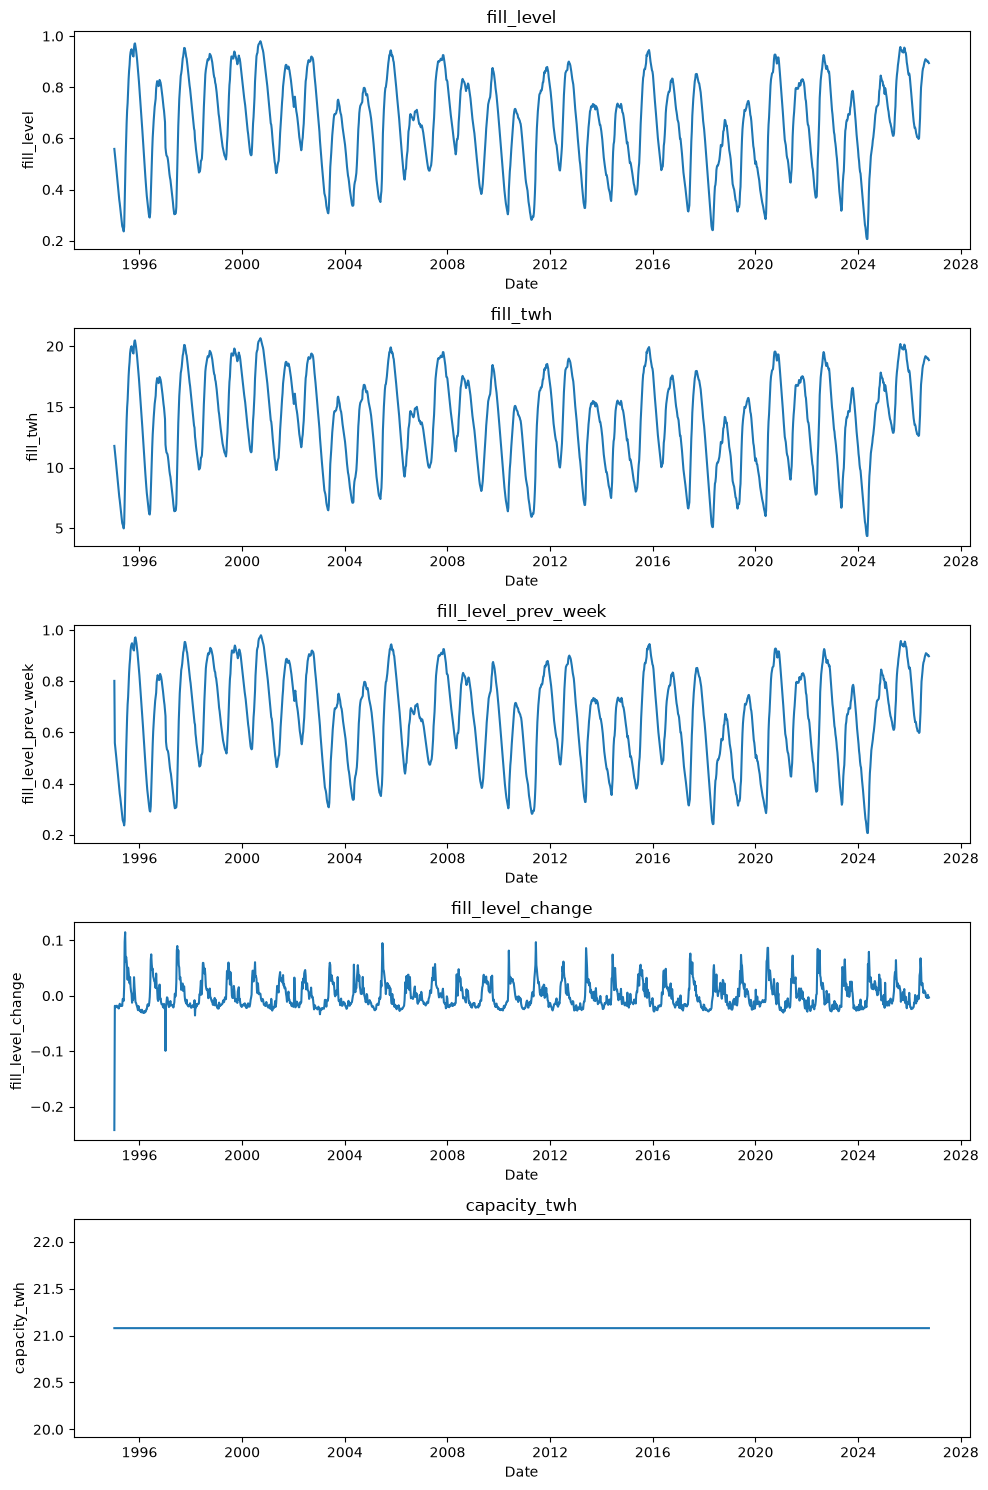

In [6]:
numeric_cols = [
    "fill_level",
    "fill_twh",
    "fill_level_prev_week",
    "fill_level_change",
    "capacity_twh",
]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))

for ax, col in zip(axes, numeric_cols):
    ax.plot(df4["date"], df4[col])
    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

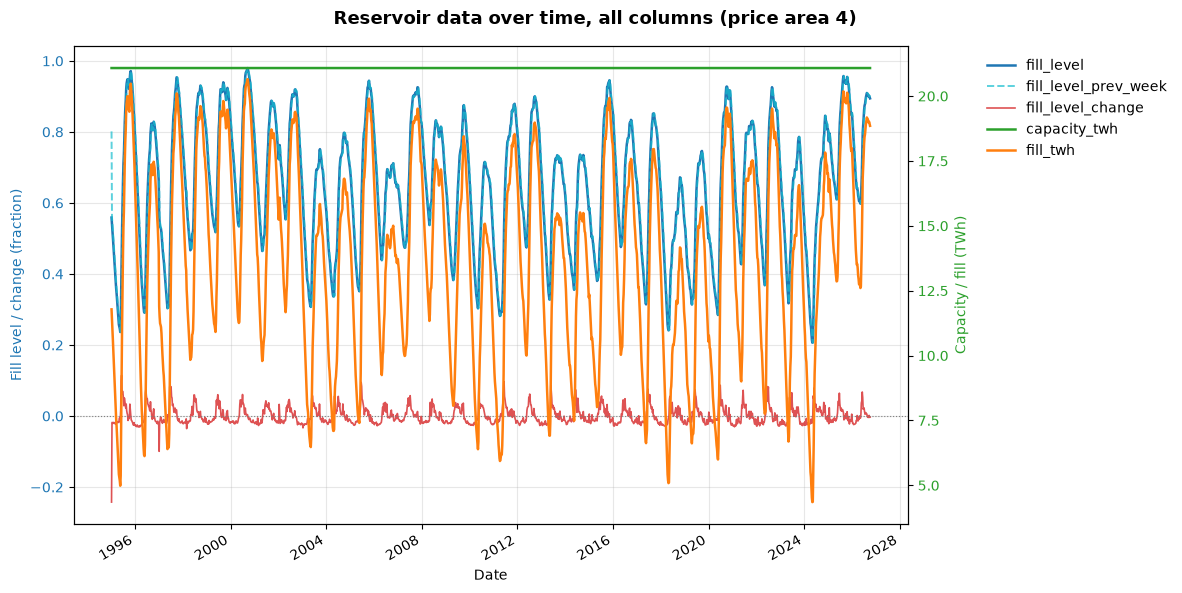

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: fractions (natural scale, roughly 0-1)
color_fill = "#1f77b4"
ax1.plot(df4["date"], df4["fill_level"], color=color_fill, linewidth=1.8, label="fill_level")
ax1.plot(df4["date"], df4["fill_level_prev_week"], color="#17becf", linewidth=1.4,
         linestyle="--", alpha=0.7, label="fill_level_prev_week")
ax1.plot(df4["date"], df4["fill_level_change"], color="#d62728", linewidth=1.2,
         alpha=0.8, label="fill_level_change")
ax1.set_xlabel("Date")
ax1.set_ylabel("Fill level / change (fraction)", color=color_fill)
ax1.tick_params(axis="y", labelcolor=color_fill)
ax1.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax1.grid(alpha=0.3)

# Right axis: TWh values
ax2 = ax1.twinx()
color_twh = "#2ca02c"
ax2.plot(df4["date"], df4["capacity_twh"], color=color_twh, linewidth=1.8, label="capacity_twh")
ax2.plot(df4["date"], df4["fill_twh"], color="#ff7f0e", linewidth=1.8, label="fill_twh")
ax2.set_ylabel("Capacity / fill (TWh)", color=color_twh)
ax2.tick_params(axis="y", labelcolor=color_twh)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", bbox_to_anchor=(1.08, 1), frameon=False)

fig.suptitle(f"Reservoir data over time, all columns (price area {AREA_OF_INTEREST})",
             fontsize=13, fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Cross-border flows from ENTSO-E

Hourly physical cross-border flows between Norwegian bidding zones and their neighbours
(Sweden, Denmark, Finland, Germany, the Netherlands and Great Britain) for 2024 and 2025
are fetched from the ENTSO-E Transparency Platform with the `entsoe-py` client. The API
token is read from `.streamlit/secrets.toml` and never stored in the notebook.

Each link is fetched in both directions: "out" is flow from Norway and "in" is flow into
Norway. Two issues needed handling:
- ENTSO-E returns each series in the time zone of its own country, so all timestamps are
  converted to UTC.
- Some series switched from hourly to 15-minute resolution, so every series is resampled
  to hourly mean MW. This makes one hourly value equal to the energy (MWh) for that hour,
  and the sums are comparable.

The requests are slow (one request per month), so the result is cached in
`data/entsoe_flows.csv` and the cell only fetches when the file is missing.

In [8]:
# Client authenticated with the token from .streamlit/secrets.toml
client = EntsoePandasClient(api_key=get_secret("entsoe", "token"))

# Norwegian zones and their foreign neighbours (cross-border links only)
LINKS = [
    ("NO_1", "SE_3"), ("NO_2", "DK_1"), ("NO_2", "DE_LU"), ("NO_2", "NL"),
    ("NO_2", "GB"), ("NO_3", "SE_2"), ("NO_4", "SE_1"), ("NO_4", "SE_2"),
    ("NO_4", "FI"),
]
START = pd.Timestamp("2024-01-01", tz="Europe/Oslo")
END = pd.Timestamp("2026-01-01", tz="Europe/Oslo")

def fetch_flow(src, dst, direction):
    """Hourly physical flow src -> dst in MW, as a long DataFrame."""
    try:
        s = client.query_crossborder_flows(src, dst, start=START, end=END)
    except NoMatchingDataError:
        return None  # no data for this link
    out = s.rename("flow_mw").reset_index()
    out.columns = ["starttime", "flow_mw"]
    out["starttime"] = out["starttime"].dt.tz_convert("UTC").dt.tz_localize(None)
    out["connection"] = f"{src.replace('_', '')}-{dst.replace('_', '')}"
    out["direction"] = direction
    return out

# For each link: "out" = from Norway, "in" = into Norway
CACHE = "data/entsoe_flows.csv"

if os.path.exists(CACHE):
    flows = pd.read_csv(CACHE, parse_dates=["starttime"])
else:
    frames = []
    for no, foreign in LINKS:
        for src, dst, d in [(no, foreign, "out"), (foreign, no, "in")]:
            f = fetch_flow(src, dst, d)
            if f is not None:
                frames.append(f)
    flows = pd.concat(frames, ignore_index=True)
    flows = (
        flows.set_index("starttime")
        .groupby(["connection", "direction"])["flow_mw"]
        .resample("h").mean().dropna()
        .reset_index()[["connection", "direction", "starttime", "flow_mw"]]
    )
    flows.to_csv(CACHE, index=False)     # inside else: only saved after a fetch

print(flows.shape)                        # outside: runs for both branches
flows.groupby(["connection", "direction"]).size()

(315792, 4)


connection  direction
DELU-NO2    in           17544
DK1-NO2     in           17544
FI-NO4      in           17544
GB-NO2      in           17544
NL-NO2      in           17544
NO1-SE3     out          17544
NO2-DELU    out          17544
NO2-DK1     out          17544
NO2-GB      out          17544
NO2-NL      out          17544
NO3-SE2     out          17544
NO4-FI      out          17544
NO4-SE1     out          17544
NO4-SE2     out          17544
SE1-NO4     in           17544
SE2-NO3     in           17544
SE2-NO4     in           17544
SE3-NO1     in           17544
dtype: int64

## 4. Writing to Cassandra with Spark

Cassandra runs locally in Docker (see `docker-compose.yml`). The table `cross_border` is
created with an explicit primary key: the partition key is (connection, direction) and
`starttime` is the clustering column, so each series is stored in time order. The data is
written with Spark and the Spark-Cassandra connector, and read back to check that the row
count (315,792) and the time range match.

In [9]:
# Treat all timestamps as UTC in both Python and Spark, so nothing shifts by 1-2 hours
os.environ["TZ"] = "UTC"
time.tzset()
spark = get_spark()
spark.conf.set("spark.sql.session.timeZone", "UTC")

ensure_keyspace()
get_cassandra_session().execute("""
    CREATE TABLE IF NOT EXISTS ind320.cross_border (
        connection text,
        direction text,
        starttime timestamp,
        flow_mw double,
        PRIMARY KEY ((connection, direction), starttime)
    )
""")

In [10]:
# Explicit schema, so Spark does not have to guess the pandas column types
schema = StructType([
    StructField("connection", StringType(), False),
    StructField("direction", StringType(), False),
    StructField("starttime", TimestampType(), False),
    StructField("flow_mw", DoubleType(), True),
])
# PySpark only accepts plain Python datetimes, not pandas Timestamps
rows = [
    (c, d, t.to_pydatetime(), float(v))
    for c, d, t, v in flows[["connection", "direction", "starttime", "flow_mw"]]
                      .itertuples(index=False, name=None)
]
sdf = spark.createDataFrame(rows, schema)

(sdf.write.format("org.apache.spark.sql.cassandra")
    .options(table="cross_border", keyspace="ind320")
    .mode("append").save())
print("Written:", sdf.count())

Written: 315792


In [11]:
cdf = (spark.read.format("org.apache.spark.sql.cassandra")
       .options(table="cross_border", keyspace="ind320").load())
print(cdf.count())
cdf.agg(F.min("starttime"), F.max("starttime")).show(truncate=False)
cdf.groupBy("connection", "direction").count().orderBy("connection", "direction").show(20)

315792


+-------------------+-------------------+
|min(starttime)     |max(starttime)     |
+-------------------+-------------------+
|2023-12-31 23:00:00|2025-12-31 22:00:00|
+-------------------+-------------------+



+----------+---------+-----+
|connection|direction|count|
+----------+---------+-----+
|  DELU-NO2|       in|17544|
|   DK1-NO2|       in|17544|
|    FI-NO4|       in|17544|
|    GB-NO2|       in|17544|
|    NL-NO2|       in|17544|
|   NO1-SE3|      out|17544|
|  NO2-DELU|      out|17544|
|   NO2-DK1|      out|17544|
|    NO2-GB|      out|17544|
|    NO2-NL|      out|17544|
|   NO3-SE2|      out|17544|
|    NO4-FI|      out|17544|
|   NO4-SE1|      out|17544|
|   NO4-SE2|      out|17544|
|   SE1-NO4|       in|17544|
|   SE2-NO3|       in|17544|
|   SE2-NO4|       in|17544|
|   SE3-NO1|       in|17544|
+----------+---------+-----+



## 5. Curating the data and loading it into MongoDB

Spark reads the table from Cassandra and extracts the columns needed by the app. The data
is limited to 2024-2025 in UTC (this removes one hour that falls in 2023), and missing
values and duplicates are dropped. A `link` field is added so both directions of the same
physical link share one name (for example `NO2-DK1`). The result is inserted into the
collection `cross_border` in MongoDB Atlas, which the Streamlit app reads.

In [12]:
# Read the table back from Cassandra with Spark
cdf = (spark.read.format("org.apache.spark.sql.cassandra")
       .options(table="cross_border", keyspace="ind320").load())

# Extract the relevant columns and curate:
#  - keep only 2024-2025 in UTC (drops the single hour that fell in 2023)
#  - drop missing values and duplicate rows
curated = (
    cdf.select("connection", "direction", "starttime", "flow_mw")
       .where((F.col("starttime") >= "2024-01-01") & (F.col("starttime") < "2026-01-01"))
       .dropna()
       .dropDuplicates(["connection", "direction", "starttime"])
)

curated_pdf = pd.DataFrame([r.asDict() for r in curated.collect()])
# One name per physical link, shared by both directions (always Norwegian zone first)
parts = curated_pdf["connection"].str.split("-", expand=True)
curated_pdf["link"] = parts[0] + "-" + parts[1]
is_in = curated_pdf["direction"] == "in"
curated_pdf.loc[is_in, "link"] = parts[1][is_in] + "-" + parts[0][is_in]

print(curated_pdf["link"].nunique(), sorted(curated_pdf["link"].unique()))
print(curated_pdf.shape)
curated_pdf.groupby(["connection", "direction"]).size().head(3)

9 ['NO1-SE3', 'NO2-DELU', 'NO2-DK1', 'NO2-GB', 'NO2-NL', 'NO3-SE2', 'NO4-FI', 'NO4-SE1', 'NO4-SE2']
(315774, 5)


connection  direction
DELU-NO2    in           17543
DK1-NO2     in           17543
FI-NO4      in           17543
dtype: int64

In [13]:
col = get_mongo_db()["cross_border"]
col.delete_many({})                       # safe to rerun

records = curated_pdf.to_dict("records")
for i in range(0, len(records), 20_000):  # insert in chunks
    col.insert_many(records[i:i + 20_000], ordered=False)

# Index that matches how the Streamlit page filters the data
col.create_index([("link", 1), ("direction", 1), ("starttime", 1)])
print("Documents in MongoDB:", col.count_documents({}))

Documents in MongoDB: 315774


In [14]:
print(col.distinct("connection"))
print(col.find_one({}, {"_id": 0}))

['DELU-NO2', 'DK1-NO2', 'FI-NO4', 'GB-NO2', 'NL-NO2', 'NO1-SE3', 'NO2-DELU', 'NO2-DK1', 'NO2-GB', 'NO2-NL', 'NO3-SE2', 'NO4-FI', 'NO4-SE1', 'NO4-SE2', 'SE1-NO4', 'SE2-NO3', 'SE2-NO4', 'SE3-NO1']
{'connection': 'GB-NO2', 'direction': 'in', 'starttime': datetime.datetime(2024, 1, 7, 14, 0), 'flow_mw': 0.0, 'link': 'NO2-GB'}


## 6. Plots

TODO: The pie chart and the line plot that the Streamlit MongoDB page reproduces.

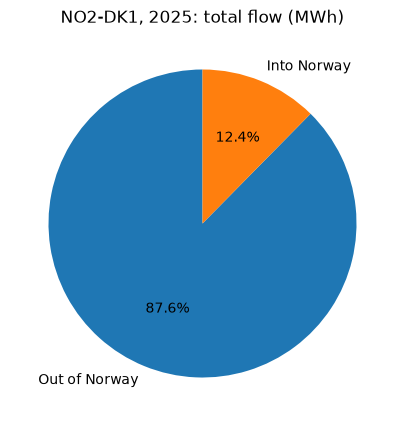

In [15]:
# Choose one link and one year
LINK = "NO2-DK1"
YEAR = 2025

d = curated_pdf[(curated_pdf["link"] == LINK) & (curated_pdf["starttime"].dt.year == YEAR)]
totals = d.groupby("direction")["flow_mw"].sum()   # hourly MW summed = MWh

plt.figure(figsize=(5, 5))
plt.pie([totals["out"], totals["in"]],
        labels=["Out of Norway", "Into Norway"], autopct="%1.1f%%", startangle=90)
plt.title(f"{LINK}, {YEAR}: total flow (MWh)")
plt.show()

## 7. AI usage

Generative AI (Claude, Anthropic) was used to:
- Set up the local environment (Docker Compose for Cassandra, PySpark with the Cassandra
  connector, Java 17) and the MongoDB Atlas connection.
- Structure the connection code into helper modules (`config.py`, `mongo_db.py`,
  `local_db.py`) and keep secrets out of git.
- Find the correct NVE API endpoint and write the data loading function, including the
  handling of the `0001-01-01` placeholder dates.
- Rewrite the Streamlit pages to use the API instead of the CSV file.

- Fetch the ENTSO-E data (including handling mixed time zones and 15-minute data), write it to Cassandra and MongoDB with Spark, and build the Streamlit pages that read from the APIs and MongoDB.

## 8. Log (compulsory work log)

Most of the time in this part went into the setup rather than the analysis. Getting Spark to talk to Cassandra was the hardest step. Java was installed with Homebrew but was not found from the notebook kernel, and I first added it to the wrong shell profile (my terminal uses bash, not zsh). I solved it by letting a helper module find Java 17 itself, so the notebook no longer depends on my shell setup. Cassandra in Docker also caused trouble: Docker froze once, and Spark kept getting "connection refused" because Cassandra needs a minute or two to start. Limiting the heap size and moving the container into a Docker Compose file with a health check fixed this, and now I can see when it is actually ready.

MongoDB Atlas gave me an authentication error for a long time, because I had copied the connection string with the placeholder password still in it. Creating a new database user solved it. Since a password had ended up in notebook output, I deleted the old user, cleared the outputs and moved all secrets to `.streamlit/secrets.toml`, which is ignored by git. A small `config.py` reads them both locally and in the app.

Replacing the CSV file with the NVE API was easy once I had the right endpoint (my first attempt returned a 404). My experience from part 1 helped: the placeholder date 0001-01-01 is converted to a missing value. I also learned that a notebook keeps an imported module in memory, so changes in `utils.py` did not show up until I restarted the kernel. Because the API is live, the data grows every week, so the plots differ slightly from part 1.

The ENTSO-E data was the most work. The client sends one request per month, so two years for nine links in two directions took around fifteen minutes, and I first thought the cell had frozen. I added a cache file after that. The series also came in different time zones, and some switched from hourly to 15-minute values, which would have made the yearly sums wrong. Converting to UTC and resampling to hourly means fixed both. Spark then refused to accept pandas timestamps, so I converted them to plain Python datetimes before writing to Cassandra. After loading the curated data into MongoDB I noticed that the two directions of a link had different names, so I added a shared `link` field and loaded the data again.

In Streamlit, splitting the code into helper modules kept the pages short. I added a page for the reservoir areas with an interval slider and radio buttons, and a page that reads from MongoDB with two columns, a pie chart, pills, a month selector and an expander documenting the source. Caching the MongoDB queries made the page respond quickly. Importing Streamlit in the notebook switched the matplotlib backend, so plots disappeared until I set the inline backend again.